In [1]:
from pathlib import Path
import os
import ast
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint

import csv
import sys

# project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
project_root = '/scratch/yl75/ak4177/src/gw_henry_fno'
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sweep.config import SWEEP_CSV_FIELDNAMES


In [15]:
# BASE_RESULTS_PATH = Path("~/Projects/groundwater/results/fno_simple_henry_sweep").expanduser()
BASE_RESULTS_PATH = Path('/scratch/yl75/ak4177/results/groundwater/fno_3d_henry_sweep')
RUN_NAME = "grid_scenarios_random_skip2_20x40_beta_test"
DATASET_NAME = "grid_scenarios_random_skip2_20x40_beta_test"

results_path = BASE_RESULTS_PATH / RUN_NAME
pprint([p.name for p in results_path.iterdir() if not p.name.startswith(".")])

['model_weights', 'sweep_results.csv', 'predictions', 'figures']


In [16]:
results_csv_path = results_path / "sweep_results.csv"
summary_results = pd.read_csv(results_csv_path)

results_summary = summary_results.sort_values(by=['scenario_name', 'total_params'])

max_transform = results_summary.groupby(['scenario_name', 'model_size_label'])['run_timestamp'].transform('max')

# results_summary = results_summary.loc[results_summary['run_timestamp'] > '2026-09-17T02:00:00']
# results_summary.groupby(['scenario_name', 'model_size_label']).agg({'run_timestamp': 'count'}).sort_values('run_timestamp', ascending=False)

results_summary = results_summary.loc[results_summary['run_timestamp']==max_transform]
results_summary = results_summary.sort_values(['scenario_name', 'total_params'])



In [17]:
model_sizes = results_summary[['model_size_label', 'total_params']].drop_duplicates().sort_values(by='total_params', ascending=True).reset_index(drop=True)
model_sizes

,model_size_label,total_params
0,small,67882


# Plot loss curve

Processing model size: small with total params: 67882
Processing model size: small with total params: 67882


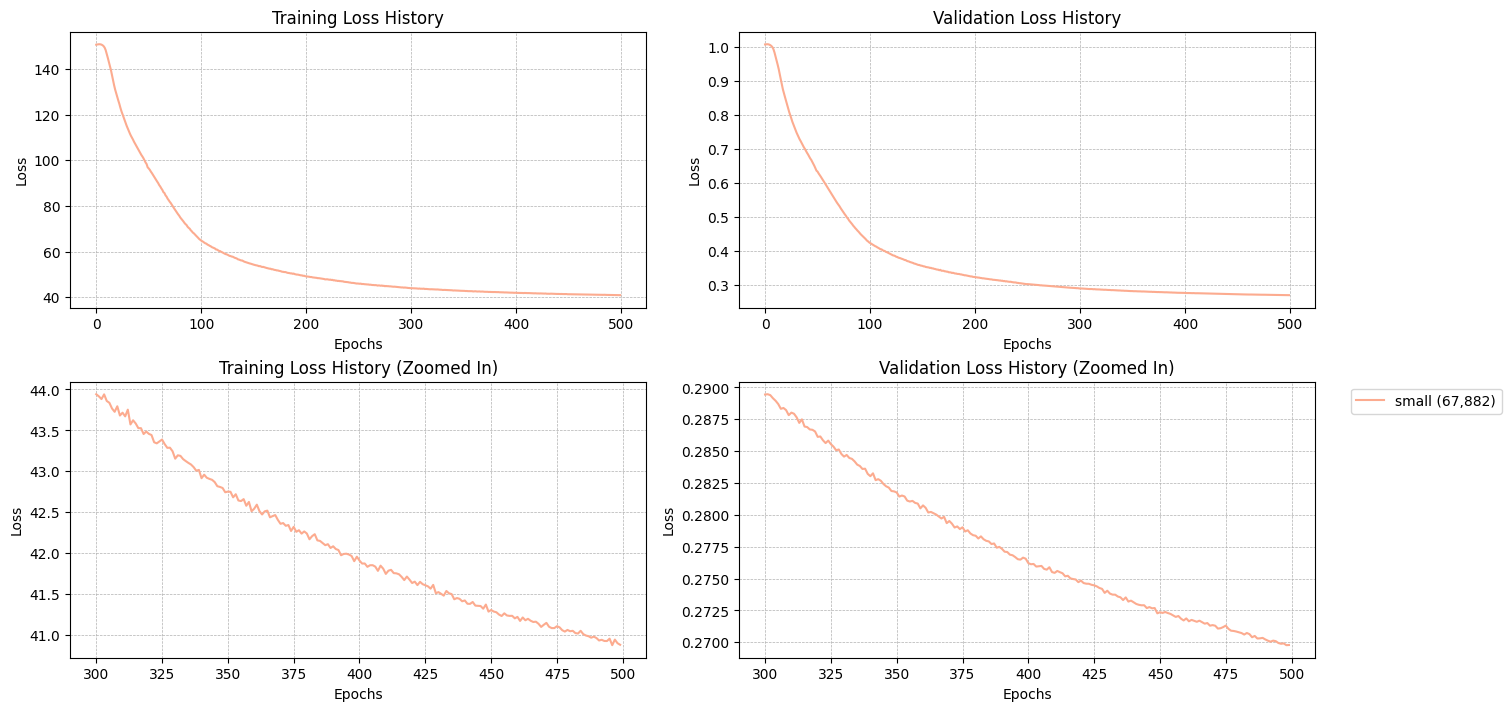

In [18]:
loss_history_parent_dir = results_path / "figures"
loss_history_files = [p.name for p in loss_history_parent_dir.iterdir() if not p.name.startswith(".")]

fig, ax = plt.subplots(2, 2, figsize=(15, 7), constrained_layout=True)
start_index = 0
end_index = 500
colors = plt.cm.Reds(np.linspace(0.3, 1, len(model_sizes)))

for (idx, model_size, total_params) in model_sizes.itertuples(index=True):
    print(f"Processing model size: {model_size} with total params: {total_params}")
    model_loss_history_file = f"{model_size}_loss_history.json"
    json_file_path = loss_history_parent_dir / model_loss_history_file
    if json_file_path.exists():
        with open(json_file_path, 'r') as f:
            loss_history = json.load(f)

        ax[0, 0].plot(np.arange(start_index, end_index), loss_history['train_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])
        ax[0, 1].plot(np.arange(start_index, end_index), loss_history['val_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])

ax[0, 0].set_title("Training Loss History")
ax[0, 0].set_xlabel("Epochs")
ax[0, 0].set_ylabel("Loss")
ax[0, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0, 1].set_title("Validation Loss History")
ax[0, 1].set_xlabel("Epochs")
ax[0, 1].set_ylabel("Loss")
ax[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)


start_index = 300
end_index = 500


for (idx, model_size, total_params) in model_sizes.itertuples(index=True):
    print(f"Processing model size: {model_size} with total params: {total_params}")
    model_loss_history_file = f"{model_size}_loss_history.json"
    json_file_path = loss_history_parent_dir / model_loss_history_file
    if json_file_path.exists():
        with open(json_file_path, 'r') as f:
            loss_history = json.load(f)

        ax[1, 0].plot(np.arange(start_index, end_index), loss_history['train_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])
        ax[1, 1].plot(np.arange(start_index, end_index), loss_history['val_loss_history'][start_index:end_index], label=f"{model_size} ({total_params:,})", color=colors[idx])

ax[1, 0].set_title("Training Loss History (Zoomed In)")
ax[1, 0].set_xlabel("Epochs")
ax[1, 0].set_ylabel("Loss")
ax[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[1, 1].set_title("Validation Loss History (Zoomed In)")
ax[1, 1].set_xlabel("Epochs")
ax[1, 1].set_ylabel("Loss")
ax[1, 1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0)) # location outside the plot

fig.savefig(results_path / "figures" / "loss_history_summary.png", bbox_inches='tight', dpi=300)
        

# Error vs Model Size

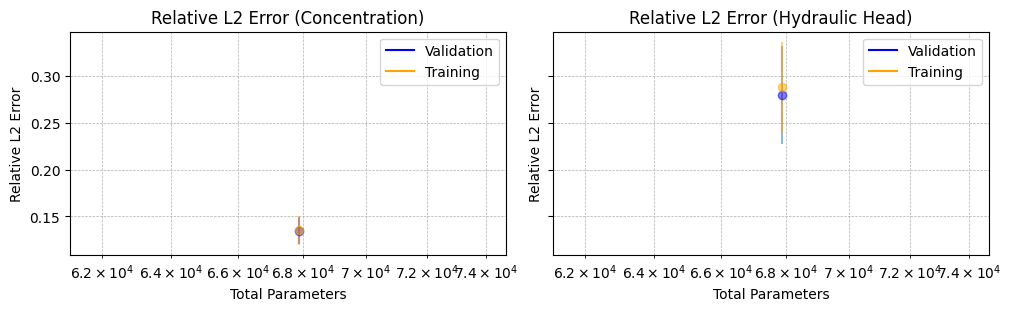

In [19]:
agg_metrics = {
    'rel_l2_error_concentration_train': ['mean', 'std'],
    'rel_l2_error_concentration_val': ['mean', 'std'],
    'rel_l2_error_hydraulic_head_train': ['mean', 'std'],
    'rel_l2_error_hydraulic_head_val': ['mean', 'std'],
}

results_summary_agg_metrics = results_summary.groupby(['model_size_label', 'total_params']).agg(agg_metrics).sort_values(by='total_params', ascending=True).reset_index()
results_summary_agg_metrics.columns = ['_'.join(col).strip('_') for col in results_summary_agg_metrics.columns.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharex=True, sharey=True, constrained_layout=True)

ax[0].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_val_mean'], label='Validation', color='blue')
ax[0].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_val_mean'], yerr=results_summary_agg_metrics['rel_l2_error_concentration_val_std'], fmt='o', color='blue', alpha=0.5)
ax[0].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_train_mean'], label='Training', color='orange')
ax[0].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_concentration_train_mean'], yerr=results_summary_agg_metrics['rel_l2_error_concentration_train_std'], fmt='o', color='orange', alpha=0.5)

ax[0].set_title("Relative L2 Error (Concentration)")
ax[0].set_xlabel("Total Parameters")
ax[0].set_ylabel("Relative L2 Error")
ax[0].set_xscale('log')
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].legend()

ax[1].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_mean'], label='Validation', color='blue')
ax[1].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_mean'], yerr=results_summary_agg_metrics['rel_l2_error_hydraulic_head_val_std'], fmt='o', markerfacecolor='blue', markeredgecolor='blue', alpha=0.5)
ax[1].plot(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_mean'], label='Training', color='orange')
ax[1].errorbar(results_summary_agg_metrics['total_params'], results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_mean'], yerr=results_summary_agg_metrics['rel_l2_error_hydraulic_head_train_std'], fmt='o', color='orange', alpha=0.5)
ax[1].set_title("Relative L2 Error (Hydraulic Head)")
ax[1].set_xlabel("Total Parameters")
ax[1].set_ylabel("Relative L2 Error")
ax[1].set_xscale('log')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[1].set_xlim(results_summary_agg_metrics['total_params'].min() * 0.9, results_summary_agg_metrics['total_params'].max() * 1.1)
ax[1].legend()

fig.savefig(results_path / "figures" / "error_summary.png", bbox_inches='tight', dpi=300)


# Error Scaling (Per Scenario)

In [20]:
# BASE_DATA_PATH = Path("~/Projects/groundwater/data/simple_henry_data").expanduser()
BASE_DATA_PATH = Path('/scratch/yl75/ak4177/data/simple_henry')
data_path = BASE_DATA_PATH / DATASET_NAME

scenarios_manifest_path = data_path / "manifest.json"
scenarios_manifest = json.load(open(scenarios_manifest_path, 'r'))['scenarios']
scenarios_manifest_df = pd.DataFrame(scenarios_manifest)[['scenario_index', 'beta_c', 'diffc']]
scenarios_manifest_df


,scenario_index,beta_c,diffc
0,1,0.00005,0.0001
1,2,0.00010,0.0001
2,3,0.00015,0.0001
3,4,0.00020,0.0001


In [22]:
results_summary['scenario_index'] = results_summary.scenario_name.apply(lambda x: int(str(x).split('_')[-1]))
results_summary_with_params = results_summary.merge(scenarios_manifest_df, how='left', on='scenario_index')
results_summary_with_params

,run_timestamp,scenario_name,model_size_label,total_params,total_norm_train,total_norm_val,rel_l2_error_concentration_train,rel_l2_error_hydraulic_head_train,rel_l2_error_concentration_val,rel_l2_error_hydraulic_head_val,scenario_index,beta_c,diffc
0,2026-09-29T16:03:28,scenario_001,small,67882,30.619335,31.290476,0.123235,0.249841,0.123654,0.235133,1,0.00005,0.0001
1,2026-09-29T16:03:35,scenario_002,small,67882,26.261127,27.277374,0.124507,0.253818,0.126044,0.244888,2,0.00010,0.0001
2,2026-09-29T16:03:41,scenario_003,small,67882,22.083578,21.986042,0.134832,0.293168,0.133401,0.289686,3,0.00015,0.0001
3,2026-09-29T16:03:47,scenario_004,small,67882,20.069937,19.566263,0.157182,0.354885,0.155504,0.349996,4,0.00020,0.0001


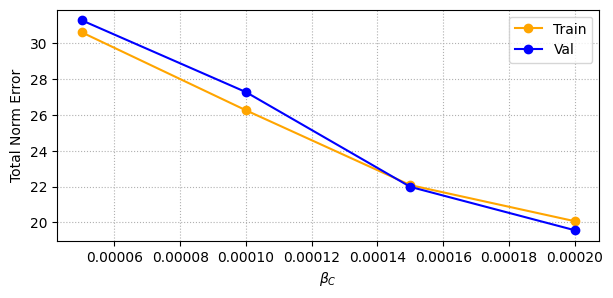

In [34]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(results_summary_with_params.beta_c, results_summary_with_params.total_norm_train, label='Train', color='orange', marker='o')
ax.plot(results_summary_with_params.beta_c, results_summary_with_params.total_norm_val, label='Val', color='blue', marker='o')

ax.set_xlabel('$\\beta_C$')
ax.set_ylabel('Total Norm Error')
ax.legend()

ax.grid(True, linestyle=':')
fig.savefig('/scratch/yl75/ak4177/src/gw_henry_fno/notebooks/test_error_beta.png', bbox_inches='tight')

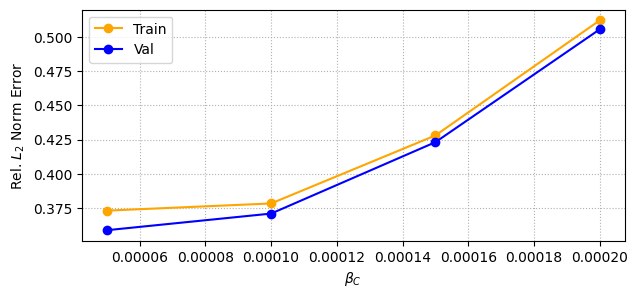

In [33]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(results_summary_with_params.beta_c, results_summary_with_params.rel_l2_error_concentration_train+results_summary_with_params.rel_l2_error_hydraulic_head_train, label='Train', color='orange', marker='o')
ax.plot(results_summary_with_params.beta_c, results_summary_with_params.rel_l2_error_concentration_val+results_summary_with_params.rel_l2_error_hydraulic_head_val, label='Val', color='blue', marker='o')

ax.set_xlabel('$\\beta_C$')
ax.set_ylabel('Rel. $L_2$ Norm Error')
ax.legend()

ax.grid(True, linestyle=':')
fig.savefig('/scratch/yl75/ak4177/src/gw_henry_fno/notebooks/test_rel_error_beta.png', bbox_inches='tight')

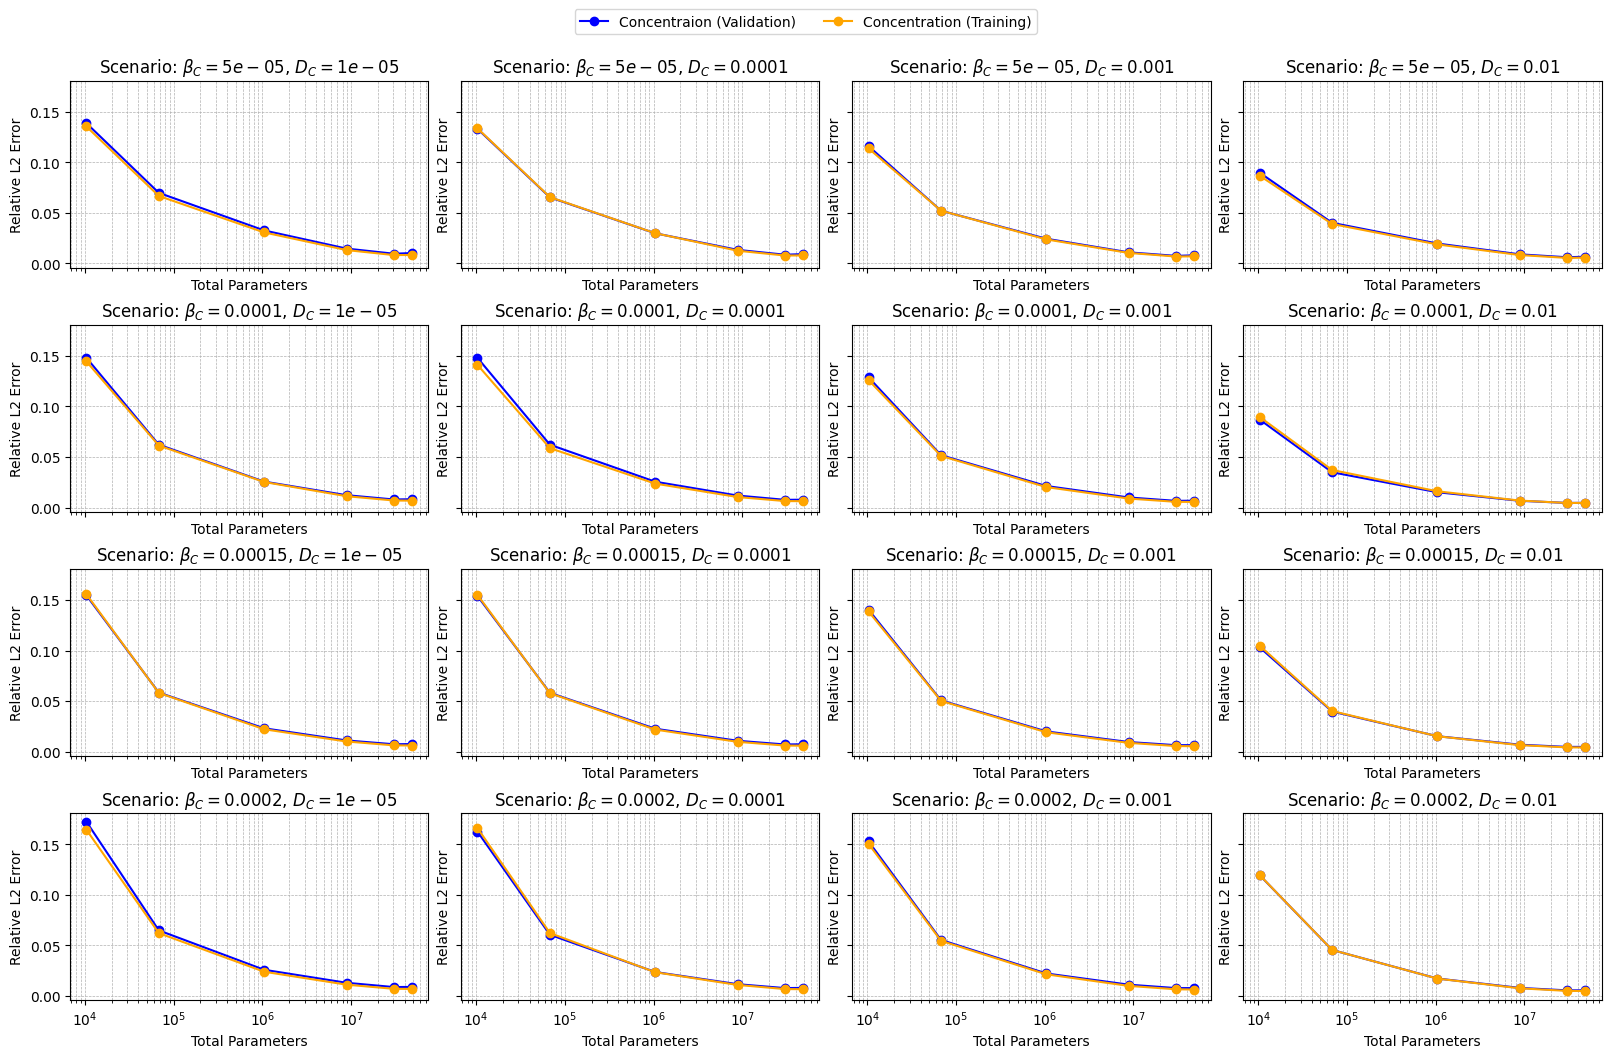

In [8]:
fig, ax = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    scenario_data = results_summary[(results_summary['scenario_name'] == scenario_name) ]
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
    scenario_beta_c = scenario_manifest['beta_c']
    scenario_diffc = scenario_manifest['diffc']

    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_val'], label='Validation', color='blue', marker='o',)
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_train'], label='Training', color='orange', marker='o',)
    # ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_val'], label='Validation', color='blue', linestyle='--', marker='x')
    # ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_train'], label='Training', color='orange', linestyle='--', marker='x')

    ax[ax_idx, ax_idy].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
    ax[ax_idx, ax_idy].set_xlabel("Total Parameters")
    ax[ax_idx, ax_idy].set_ylabel("Relative L2 Error")
    ax[ax_idx, ax_idy].set_xscale('log')
    ax[ax_idx, ax_idy].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0, 0].get_legend_handles_labels()
labels = ['Concentraion (Validation)', 'Concentration (Training)'] #, 'Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

fig.savefig(results_path / "figures" / "error_summary_by_scenario.png", bbox_inches='tight', dpi=300)

In [9]:
scenario_data

,run_timestamp,scenario_name,model_size_label,total_params,rel_l2_error_concentration_train,rel_l2_error_hydraulic_head_train,rel_l2_error_concentration_val,rel_l2_error_hydraulic_head_val
175,2026-09-29T01:45:43,scenario_016,tiny,10326,0.119462,0.130854,0.119337,0.131363
139,2026-09-29T01:12:25,scenario_016,small,67882,0.045335,0.055282,0.045327,0.055975
143,2026-09-29T01:12:45,scenario_016,medium,1044082,0.016998,0.017965,0.017087,0.018480
159,2026-09-29T01:21:19,scenario_016,large,8872162,0.007402,0.008425,0.007800,0.009038
191,2026-09-29T02:01:27,scenario_016,huge,30453586,0.004845,0.005360,0.005353,0.006059
207,2026-09-29T02:55:38,scenario_016,massive,48705970,0.004756,0.004940,0.005423,0.005885


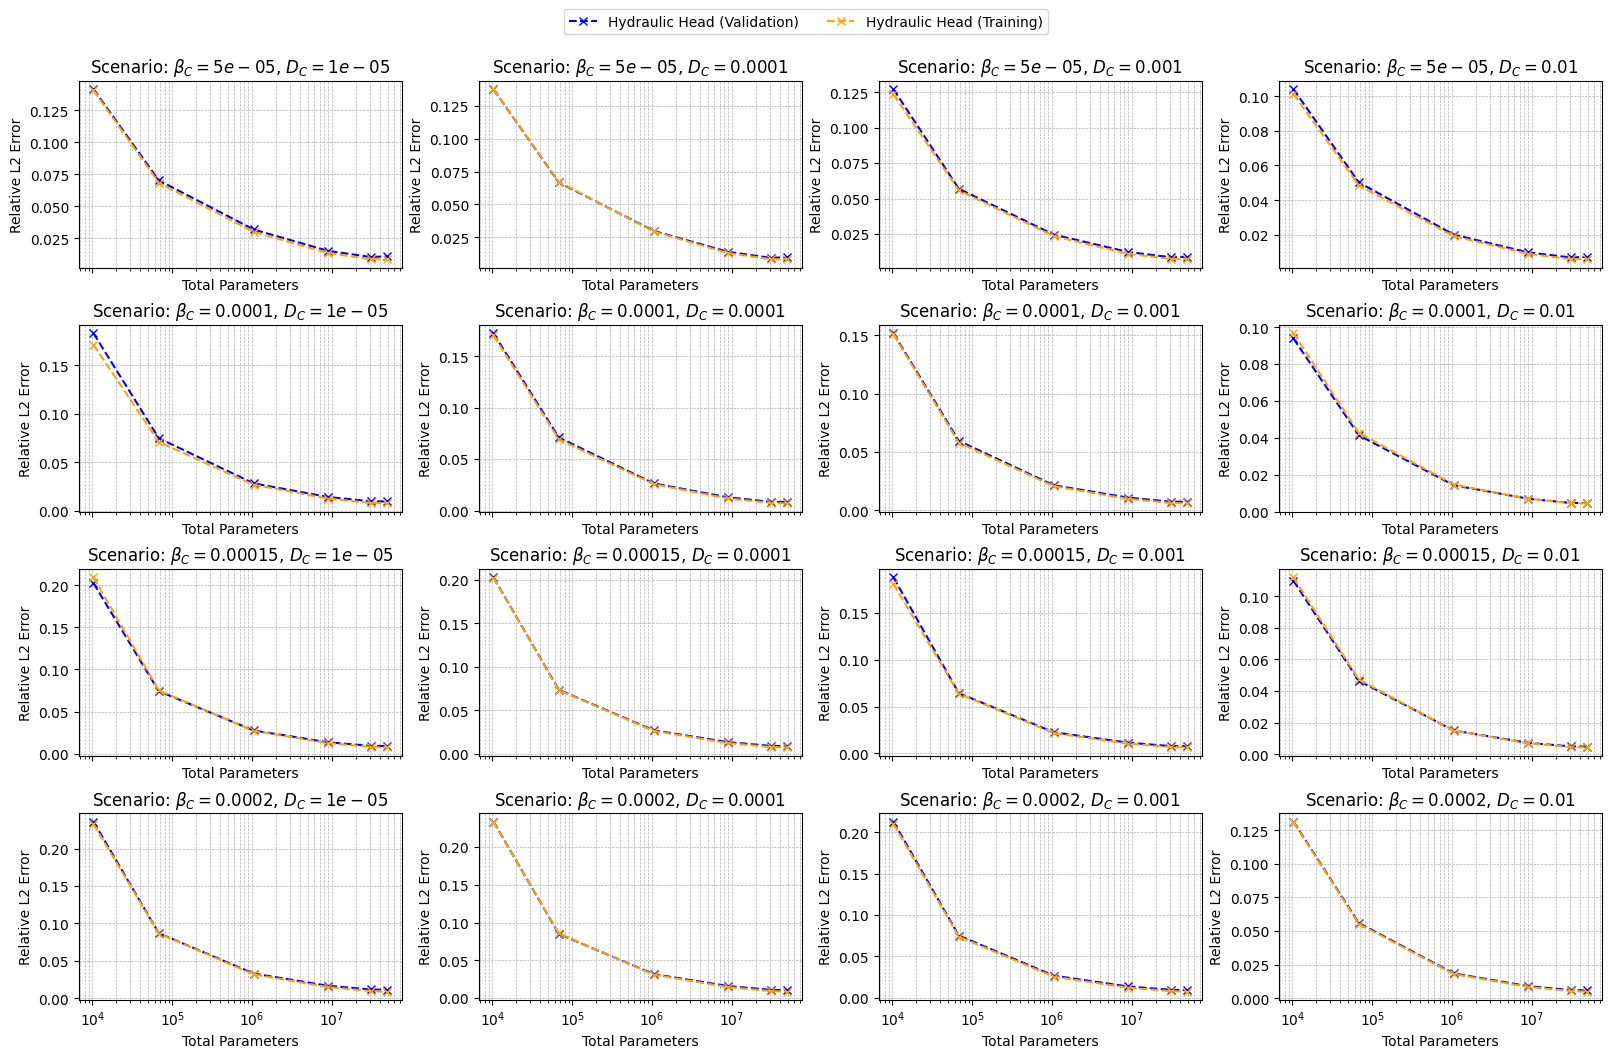

In [10]:
fig, ax = plt.subplots(4, 4, figsize=(16, 10), sharex=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    scenario_data = results_summary[results_summary['scenario_name'] == scenario_name]
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
    scenario_beta_c = scenario_manifest['beta_c']
    scenario_diffc = scenario_manifest['diffc']
    
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_val'], label='Validation', color='blue', linestyle='--', marker='x')
    ax[ax_idx, ax_idy].plot(scenario_data['total_params'], scenario_data['rel_l2_error_hydraulic_head_train'], label='Training', color='orange', linestyle='--', marker='x')

    ax[ax_idx, ax_idy].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
    ax[ax_idx, ax_idy].set_xlabel("Total Parameters")
    ax[ax_idx, ax_idy].set_ylabel("Relative L2 Error")
    ax[ax_idx, ax_idy].set_xscale('log')
    ax[ax_idx, ax_idy].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0, 0].get_legend_handles_labels()
labels = ['Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

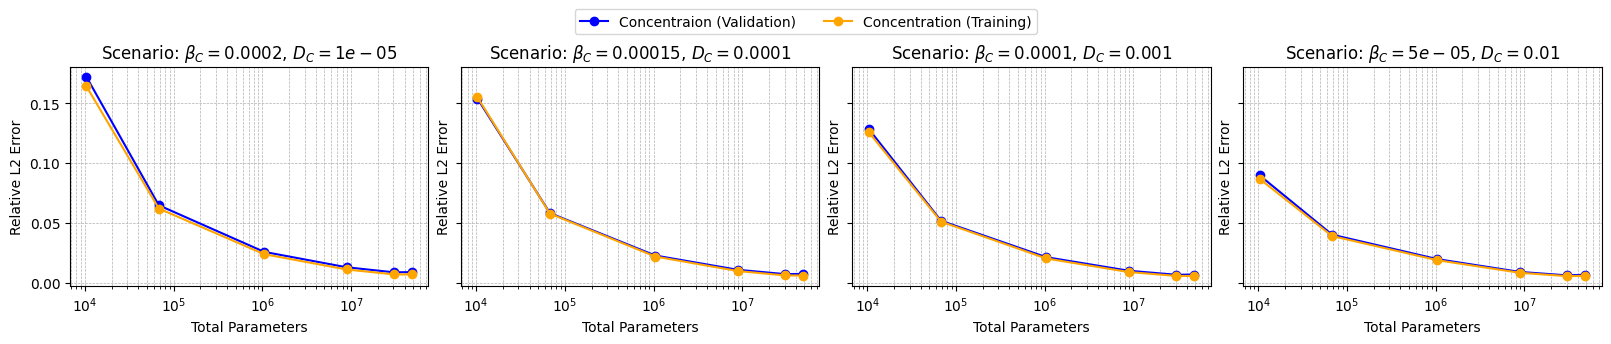

In [11]:
# Plot the right diagonal of the 4x4 grid for hydraulic head errors
fig, ax = plt.subplots(1, 4, figsize=(16, 3), sharex=True, sharey=True, constrained_layout=True)

for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):

    idx = (scenario_idx) // 4
    idy = (scenario_idx) % 4

    if idx + idy == 3:  # Only plot for the right diagonal
        scenario_data = results_summary[results_summary['scenario_name'] == scenario_name]

        scenario_manifest = scenarios_manifest_df[scenarios_manifest_df['scenario_index'] == scenario_idx+1].iloc[0]
        scenario_beta_c = scenario_manifest['beta_c']
        scenario_diffc = scenario_manifest['diffc']
        
        ax[scenario_idx % 4].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_val'], label='Validation', color='blue', linestyle='-', marker='o')
        ax[scenario_idx % 4].plot(scenario_data['total_params'], scenario_data['rel_l2_error_concentration_train'], label='Training', color='orange', linestyle='-', marker='o')

        ax[scenario_idx % 4].set_title(f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$")
        ax[scenario_idx % 4].set_xlabel("Total Parameters")
        ax[scenario_idx % 4].set_ylabel("Relative L2 Error")
        ax[scenario_idx % 4].set_xscale('log')
        ax[scenario_idx % 4].grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend to avoid duplicate labels
handles, labels = ax[0].get_legend_handles_labels()
labels = ['Concentraion (Validation)', 'Concentration (Training)'] #, 'Hydraulic Head (Validation)', 'Hydraulic Head (Training)']
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.12))

fig.savefig(results_path / "figures" / "error_summary_by_scenario_diagonal.png", bbox_inches='tight', dpi=300)

# Compare Simulated and Predicted Concentration Fields

In [12]:
diag_scenarios = []
for scenario_idx, scenario_name in enumerate(results_summary['scenario_name'].unique()):
    idx = (scenario_idx) // 4
    idy = (scenario_idx) % 4

    if idx + idy == 3:  # Only plot for the right diagonal
        diag_scenarios.append(scenario_name)

diag_scenarios

['scenario_004', 'scenario_007', 'scenario_010', 'scenario_013']

In [13]:
scenarios_for_preds = [f'scenario_{idx:03d}' for idx in range(13, 17)]
scenarios_for_preds

['scenario_013', 'scenario_014', 'scenario_015', 'scenario_016']

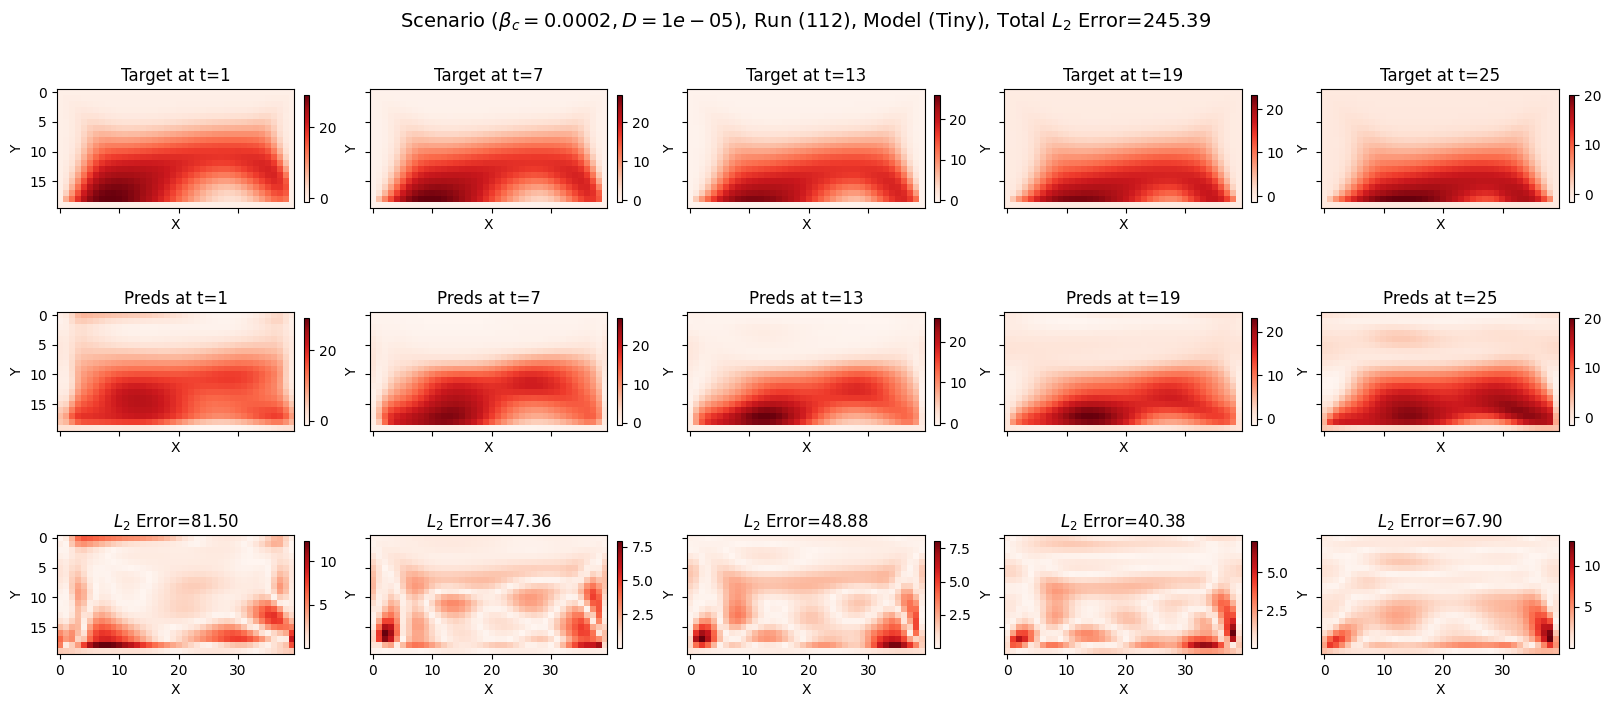

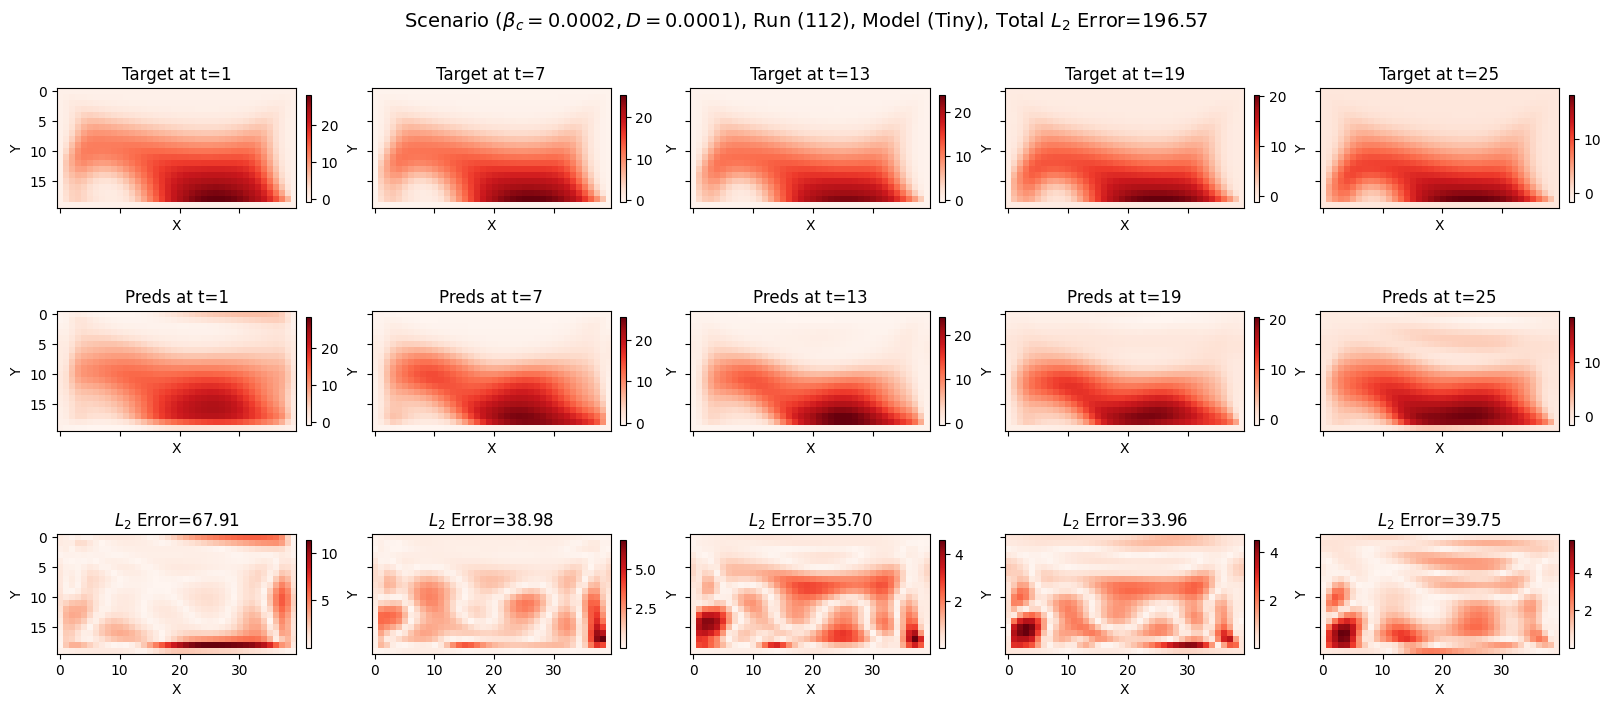

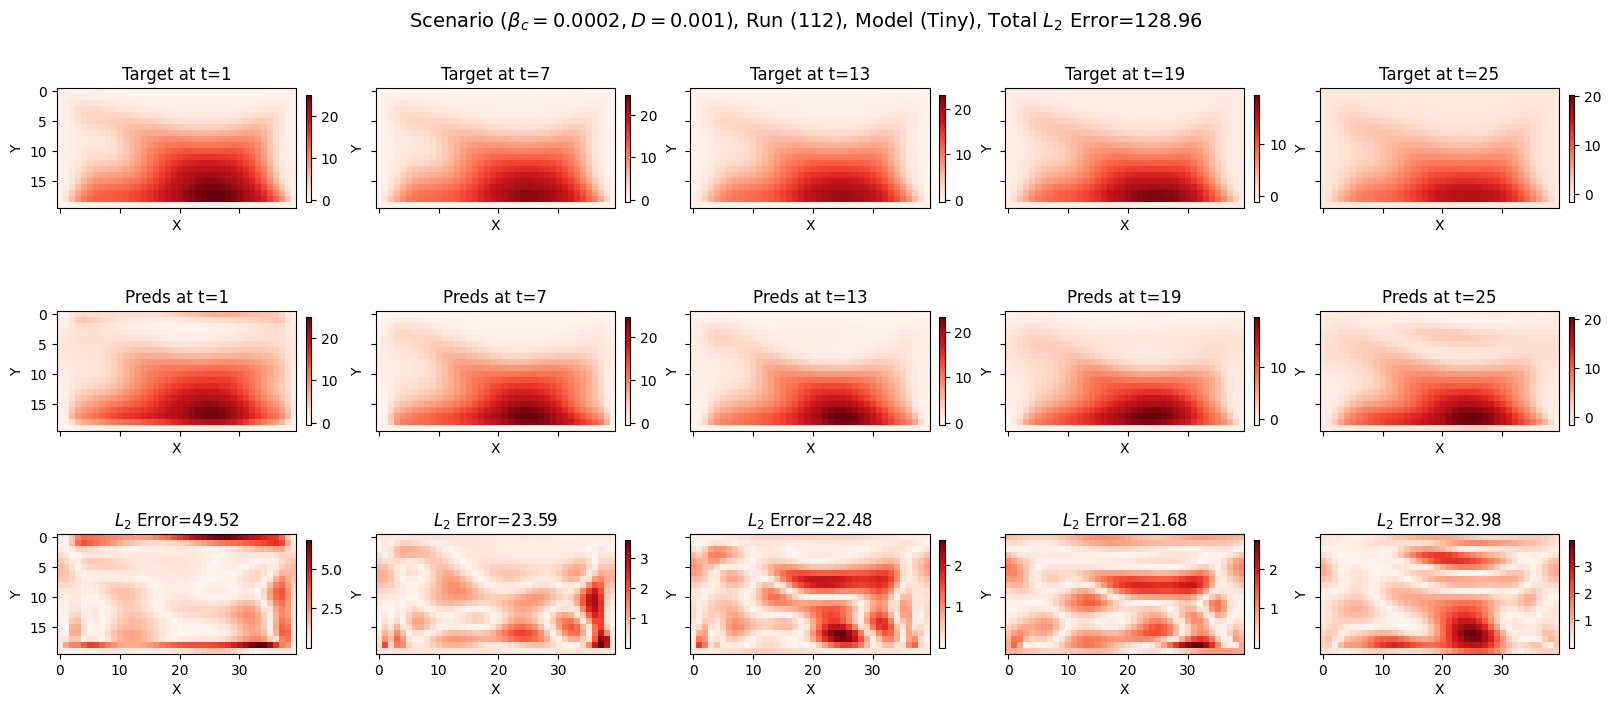

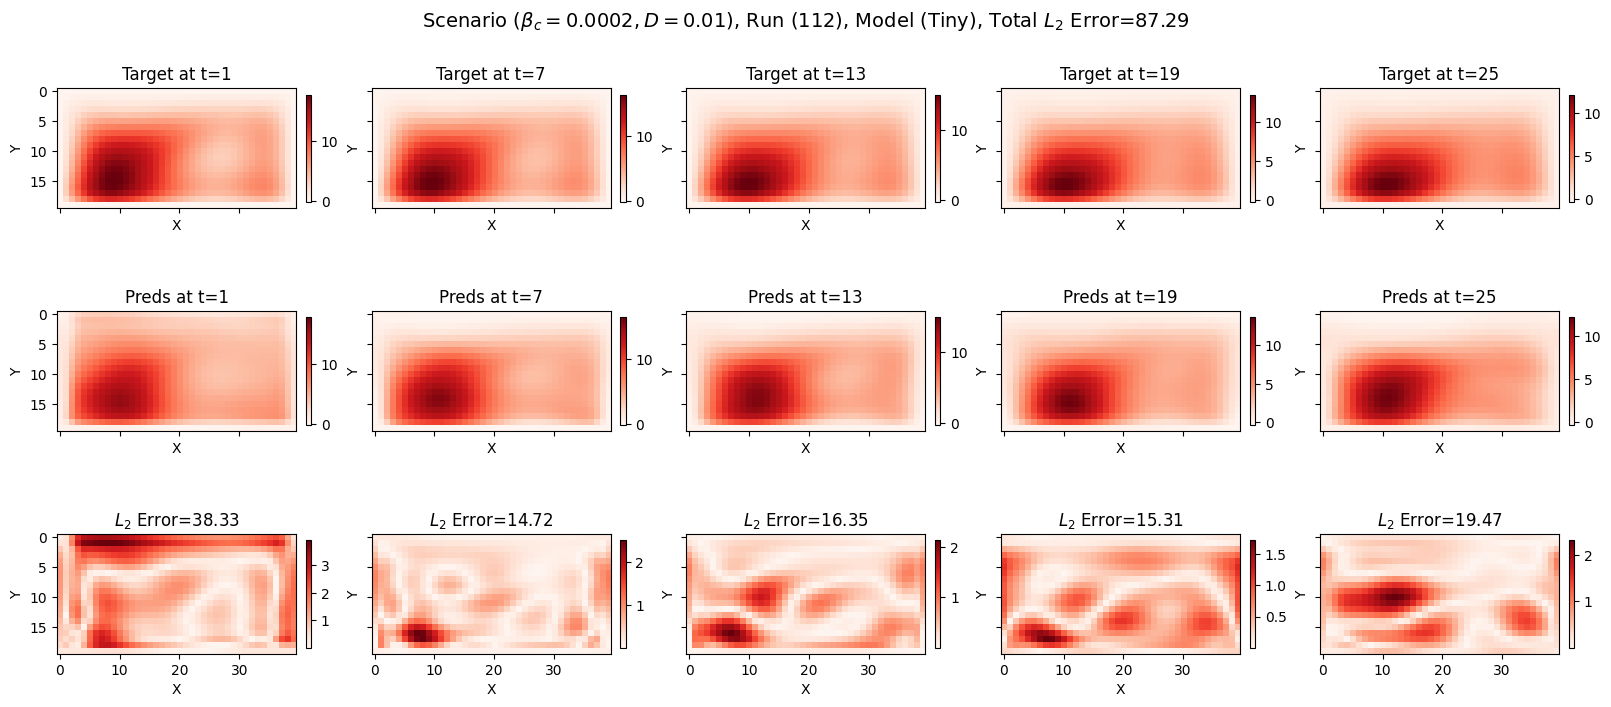

In [14]:
prediction_npz_dir = results_path / "predictions"
model_sizes_for_preds = model_sizes['model_size_label'].tolist()
model_sizes_for_preds = model_sizes_for_preds[:1]

npz_files = [
    p for p in prediction_npz_dir.iterdir()
    if p.suffix == '.npz' 
    and '_'.join(p.name.split('_')[0:2]) in scenarios_for_preds 
    and p.name.split('_')[-1].split('.')[0] in model_sizes_for_preds
]
npz_files.sort(key=lambda x: (x.name.split('_')[-1], int(x.name.split('_')[1])))

run_idx = np.random.randint(150)

for npz_file in npz_files:
    data = np.load(npz_file)
    val_preds = data['train_preds']
    val_targets = data['train_targets']

    scenario_manifest = scenarios_manifest_df[
        scenarios_manifest_df['scenario_index'] == int(npz_file.name.split('_')[1])
    ].iloc[0]
    beta_c = scenario_manifest['beta_c']
    diffc = scenario_manifest['diffc']

    model_size_label = npz_file.name.split('_')[-1].split('.')[0]

    T = val_preds.shape[1]
    ts_to_plot = np.linspace(0, T - 1, 5, dtype=int)
    fig, ax = plt.subplots(3, 5, figsize=(16, 7), sharex=True, sharey=True, constrained_layout=True)

    for idx, t in enumerate(ts_to_plot):
        pred_t = val_preds[run_idx, t, :, :, 0]
        target_t = val_targets[run_idx, t, :, :, 0]
        
        vmin = min(target_t.min(), pred_t.min())
        vmax = max(target_t.max(), pred_t.max())

        # Target field
        im = ax[0, idx].imshow(target_t, cmap='Reds', vmin=vmin, vmax=vmax)
        ax[0, idx].set_title(f'Target at t={t+1}')
        ax[0, idx].set_ylabel('Y')
        ax[0, idx].set_xlabel('X')
        fig.colorbar(im, ax=ax[0, idx], fraction=0.046, pad=0.04, shrink=0.5)

        # Prediction field
        im = ax[1, idx].imshow(pred_t, cmap='Reds', vmin=vmin, vmax=vmax)
        ax[1, idx].set_title(f'Preds at t={t+1}')
        ax[1, idx].set_ylabel('Y')
        ax[1, idx].set_xlabel('X')
        fig.colorbar(im, ax=ax[1, idx], fraction=0.046, pad=0.04, shrink=0.5)

        # L2 norm error
        diff_t = pred_t - target_t
        l2_t = np.linalg.norm(diff_t)                     # Scalar Frobenius/L2 norm over the 2D grid
        # For relative L2 norm, use: l2_t = np.linalg.norm(diff_t) / (np.linalg.norm(target_t) + 1e-8)

        # Spatial plot: magnitude |pred - target| or squared diff (diff_t**2)
        im = ax[2, idx].imshow(np.abs(diff_t), cmap='Reds')
        ax[2, idx].set_title(f'$L_2$ Error={l2_t:.2f}')
        ax[2, idx].set_ylabel('Y')
        ax[2, idx].set_xlabel('X')
        fig.colorbar(im, ax=ax[2, idx], fraction=0.046, pad=0.04, shrink=0.5)

    # Total L2 norm across all space and time for this run
    total_l2 = np.linalg.norm(val_preds[run_idx] - val_targets[run_idx])
    # For relative total L2, use: total_l2 = np.linalg.norm(...) / np.linalg.norm(val_targets[run_idx])

    fig.suptitle(
        f"Scenario ($\\beta_c={beta_c}, D={diffc}$), Run ({run_idx+1}), "
        f"Model ({model_size_label.capitalize()}), Total $L_2$ Error={total_l2:.2f}",
        fontsize=14
    )

    fig.savefig(
        results_path / "figures" / f"l2_spatial_error_scenario_{npz_file.name.split('_')[1]}_model_{model_size_label}.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.show()
    plt.close()

In [15]:
import numpy as np

def compute_rel_l2_per_channel(
    targets: np.ndarray,
    preds: np.ndarray,
) -> tuple[float, float]:
    """Compute per-channel relative L2 error averaged over all runs.

    Parameters
    ----------
    targets : np.ndarray
        Denormalised ground-truth array, shape ``(N, T, Z, X, C_out)``.
    preds : np.ndarray
        Denormalised predicted array, shape ``(N, T, Z, X, C_out)``.

    Returns
    -------
    rel_l2_ch0, rel_l2_ch1
        Scalar relative L2 error for channel 0 (concentration) and
        channel 1 (hydraulic head), averaged over all N runs.
    """
    N = targets.shape[0]
    C_out = targets.shape[-1]

    # Flatten all spatial/temporal dims: (N, T*Z*X, C_out)
    flat_targets = targets.reshape(N, -1, C_out)
    flat_preds = preds.reshape(N, -1, C_out)

    # 1. Compute absolute L2 norm of the difference (Numerator)
    diff = flat_preds - flat_targets                         # (N, T*Z*X, C_out)
    diff_norm = np.linalg.norm(diff, axis=1)                 # (N, C_out)
    
    # 2. Compute absolute L2 norm of the ground truth (Denominator)
    gt_norm = np.linalg.norm(flat_targets, axis=1)           # (N, C_out)
    
    # 3. Calculate relative error per run
    rel_l2 = diff_norm / (gt_norm + 1e-12)                   # (N, C_out)

    # 4. Average across all independent validation runs
    mean_rel_l2 = rel_l2.mean(axis=0)                        # (C_out,)
    
    return float(mean_rel_l2[0]), float(mean_rel_l2[1])

In [18]:
def compute_total_norm_error(targets, preds, dt, dz, dx):

    # Compute area of the domain
    area = dz * dx

    # Residual
    diff = preds - targets
    
    # Assuming Channel 0 = Concentration (C), Channel 1 = Pressure/Head (p)
    diff_c = diff[..., 0]  # shape: (N, T, Z, X)
    diff_h = diff[..., 1]  # shape: (N, T, Z, X)

    # =====================================================================
    # 1. Concentration Norm: ||C||_{\mathcal{C}_T}
    # =====================================================================
    l2_sq_c_space = np.sum(diff_c**2, axis=(2, 3)) * area 
    l_inf_l2_sq_c = np.max(l2_sq_c_space, axis=1)  

    # Sum over time of spatial gradient L2 norm squared
    # Compute spatial gradients over Z (axis 2) and X (axis 3) using actual spacing
    grad_c_z, grad_c_x = np.gradient(diff_c, dz, dx, axis=(2, 3))
    
    grad_c_l2_sq_space = np.sum(grad_c_z**2 + grad_c_x**2, axis=(2, 3)) * area 
    grad_c_l2_l2_sq = np.sum(grad_c_l2_sq_space, axis=1) * dt                

    # Final C norm for each run
    norm_c = np.sqrt(l_inf_l2_sq_c + grad_c_l2_l2_sq) 

    # =====================================================================
    # 2. Pressure/Head Norm: ||p||_{L^\infty H^1}
    # =====================================================================
    # Spatial L2 norm squared at each time step
    l2_sq_h_space = np.sum(diff_h**2, axis=(2, 3)) * area 

    # Spatial gradient L2 norm squared at each time step
    grad_h_z, grad_h_x = np.gradient(diff_h, dz, dx, axis=(2, 3))
    grad_h_l2_sq_space = np.sum(grad_h_z**2 + grad_h_x**2, axis=(2, 3)) * area 

    # ||p(t)||_{H^1}^2 = L2^2 + \nabla L2^2
    h1_sq_h = l2_sq_h_space + grad_h_l2_sq_space 

    # Final p norm for each run: Max over time of the H^1 norm
    norm_h = np.max(np.sqrt(h1_sq_h), axis=1) 

    # =====================================================================
    # 3. Combined Total Metric: ||(C, p)||_{\mathcal{Z}_T}
    # =====================================================================
    total_norm = norm_c + norm_h 

    return total_norm



In [21]:
import numpy as np

prediction_npz_dir = results_path / "predictions"

# Grid and time parameters from Section 3.1
dx = 0.05
dz = 0.05
area = dx * dz
dt = 2.0 / 50  # T=2.0 days, 100 time steps with skip=2

npz_errors = {}
for npz_file in sorted(prediction_npz_dir.glob("*.npz")):
    parts = npz_file.stem.split("_")
    scenario_num = int(parts[1])
    model_size_label = parts[-1]

    data = np.load(npz_file)
    preds = data["val_preds"]      # shape: (N, T, Y, X, C=2)
    targets = data["val_targets"]  # same shape

    total_norm = compute_total_norm_error(targets, preds,
                                          dx=dx, dz=dz, dt=dt)

    # norm_c, norm_h = compute_rel_l2_per_channel(targets, preds)
    # total_norm = norm_c + norm_h
    
    # Average the metric across all independent validation runs
    metric_value = np.mean(total_norm)

    if scenario_num not in npz_errors:
        npz_errors[scenario_num] = {}
    npz_errors[scenario_num][model_size_label] = metric_value

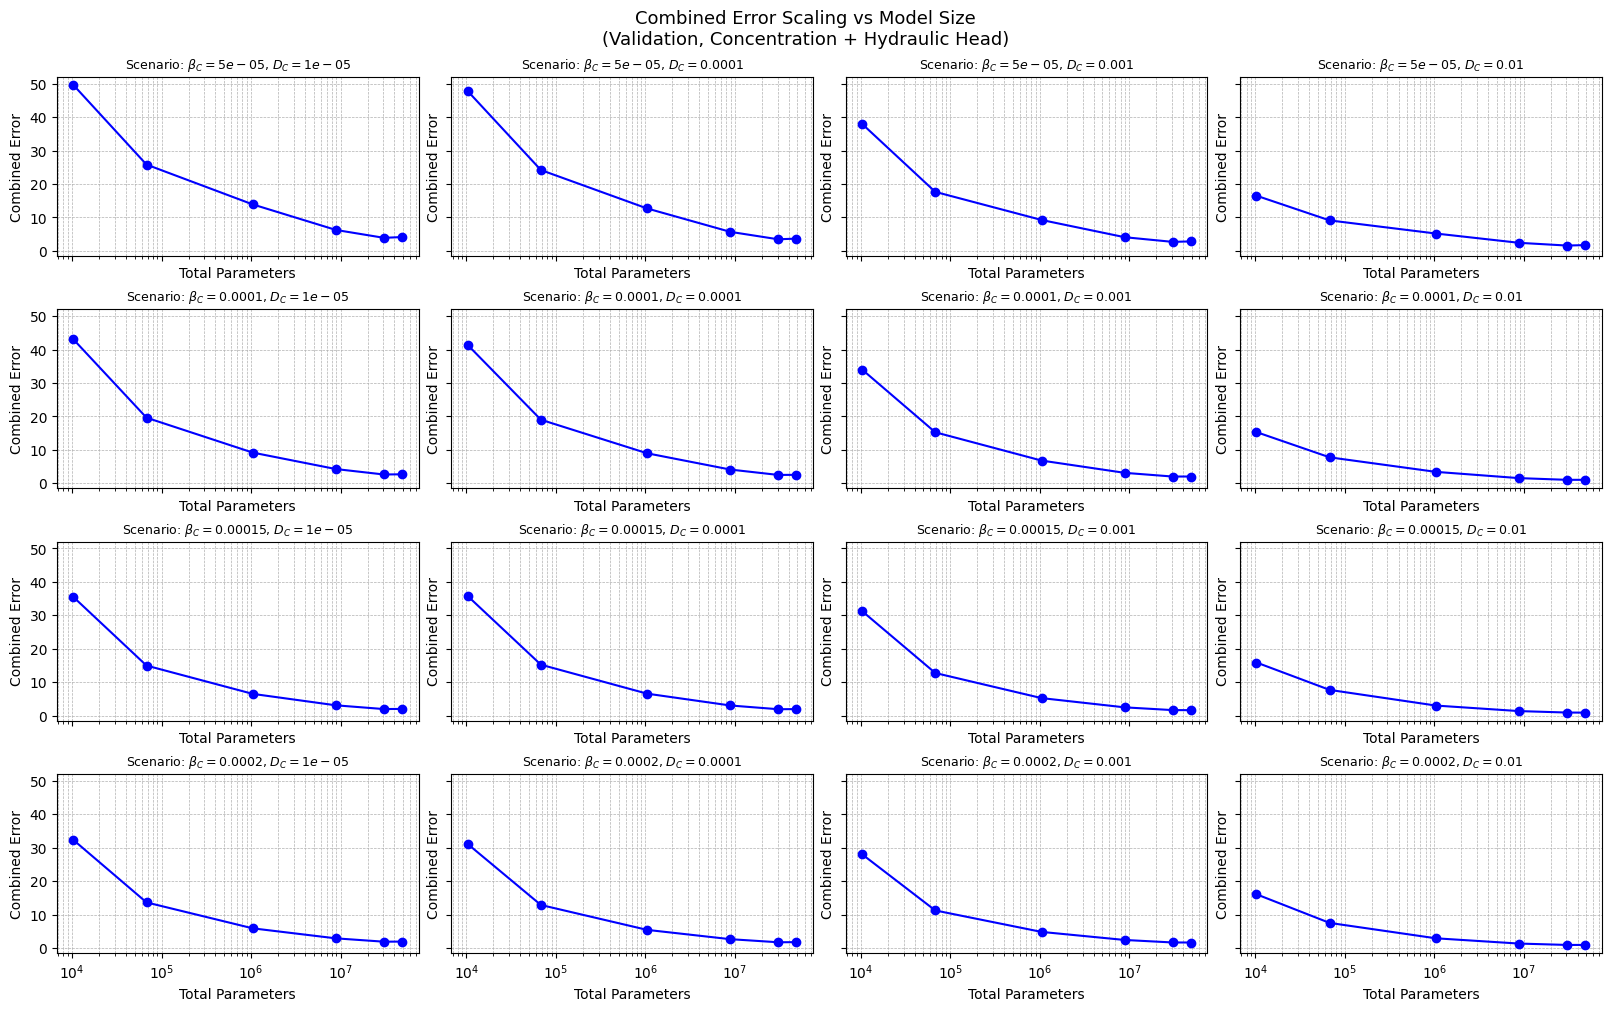

In [22]:


# --- Plot: 4x4 grid (one subplot per scenario) ---
fig, ax = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)

model_size_order = model_sizes["model_size_label"].tolist()
param_counts = model_sizes.set_index("model_size_label")["total_params"].to_dict()

for scenario_idx, scenario_name in enumerate(results_summary["scenario_name"].unique()):
    scenario_num = scenario_idx + 1
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    scenario_manifest = scenarios_manifest_df[
        scenarios_manifest_df["scenario_index"] == scenario_num
    ].iloc[0]
    scenario_beta_c = scenario_manifest["beta_c"]
    scenario_diffc = scenario_manifest["diffc"]

    if scenario_num not in npz_errors:
        continue

    total_params_list = []
    combined_errors = []

    for ms_label in model_size_order:
        if ms_label in npz_errors[scenario_num]:
            total_params_list.append(param_counts[ms_label])
            combined_errors.append(npz_errors[scenario_num][ms_label])

    ax[ax_idx, ax_idy].plot(
        total_params_list, combined_errors,
        color="blue", linestyle="-", marker="o"
    )

    ax[ax_idx, ax_idy].set_title(
        f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$", fontsize=9
    )
    ax[ax_idx, ax_idy].set_xlabel("Total Parameters")
    ax[ax_idx, ax_idy].set_ylabel("Combined Error")
    ax[ax_idx, ax_idy].set_xscale("log")
    ax[ax_idx, ax_idy].grid(True, which="both", linestyle="--", linewidth=0.5)

fig.suptitle(
    "Combined Error Scaling vs Model Size\n(Validation, Concentration + Hydraulic Head)",
    fontsize=13
)

fig.savefig(
    results_path / "figures" / "error_scaling_combined_from_npz.png",
    bbox_inches="tight", dpi=300
)
plt.show()
plt.close()


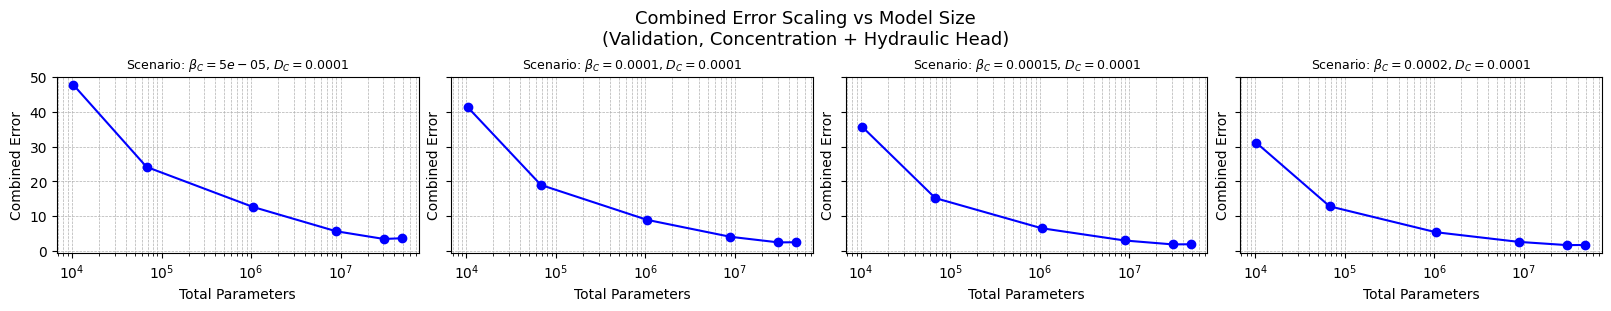

In [23]:
# --- Plot: 4x4 grid (one subplot per scenario) ---
fig, ax = plt.subplots(1, 4, figsize=(16, 3), sharex=True, sharey=True, constrained_layout=True)

model_size_order = model_sizes["model_size_label"].tolist()
param_counts = model_sizes.set_index("model_size_label")["total_params"].to_dict()

for scenario_idx, scenario_name in enumerate(results_summary["scenario_name"].unique()):
    scenario_num = scenario_idx + 1
    ax_idx = scenario_idx // 4
    ax_idy = scenario_idx % 4

    if ax_idy == 1:  # Only plot for the right diagonal

        scenario_manifest = scenarios_manifest_df[
            scenarios_manifest_df["scenario_index"] == scenario_num
        ].iloc[0]
        scenario_beta_c = scenario_manifest["beta_c"]
        scenario_diffc = scenario_manifest["diffc"]
    
        if scenario_num not in npz_errors:
            continue
    
        total_params_list = []
        combined_errors = []
    
        for ms_label in model_size_order:
            if ms_label in npz_errors[scenario_num]:
                total_params_list.append(param_counts[ms_label])
                combined_errors.append(npz_errors[scenario_num][ms_label])
    
        ax[scenario_idx // 4].plot(
            total_params_list, combined_errors,
            color="blue", linestyle="-", marker="o"
        )
    
        ax[scenario_idx // 4].set_title(
            f"Scenario: $\\beta_C={scenario_beta_c}$, $D_C={scenario_diffc}$", fontsize=9
        )
        ax[scenario_idx // 4].set_xlabel("Total Parameters")
        ax[scenario_idx // 4].set_ylabel("Combined Error")
        ax[scenario_idx // 4].set_xscale("log")
        ax[scenario_idx // 4].grid(True, which="both", linestyle="--", linewidth=0.5)

fig.suptitle(
    "Combined Error Scaling vs Model Size\n(Validation, Concentration + Hydraulic Head)",
    fontsize=13
)

fig.savefig(
    results_path / "figures" / "error_scaling_combined_from_npz_vert.png",
    bbox_inches="tight", dpi=300
)
plt.show()
plt.close()

In [25]:
dt, dx, dz

(0.04, 0.05, 0.05)